# L5b Advanced: Frontier Geometry and the Two-Fund Theorem

For a specified expected growth rate, which portfolio has the smallest variance? The [L5b lecture](../../CHEME-5660-L5b-Lecture-MAGBM-Data-Portfolios-Fall-2026.ipynb) introduced the minimum-variance frontier that answers this question. Here, we derive its weights and examine why a curved frontier in the risk-growth plane can be generated by combining just two fixed portfolios.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Derive the minimum-variance frontier:** Use the budget and target-growth constraints to obtain closed-form portfolio weights and variance, and check the result against a numerical solver.
> - **Explain the two-fund theorem:** Show how combining two distinct frontier portfolios generates the unconstrained frontier, including combinations that require short positions in one fund.
> - **Compare weight constraints:** Compute frontiers with a position-size limit and with long-only weights, and measure the increase in growth-rate standard deviation at a common target.

In this example, we use the same thirteen firms and 2014–2024 training data as the L5b minimum-variance example. We first allow short positions, derive the frontier, and verify the two-fund combinations. We then compare two restrictions separately: limiting each position to half the initial budget in magnitude, and requiring all weights to be nonnegative.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # Load the local setup file.

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

### Data
The training dataset contains daily price records from January 3, 2014 through December 31, 2024. We use each day's __volume-weighted average price (VWAP)__ as our share-price observation. It averages transaction prices using the number of shares traded as weights and is stored in the `volume_weighted_average_price` column.

Let's load the price histories using [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). Some firms have shorter histories than others. We retain those with the same number of price records as `AAPL`, which has a full history over this period. We store the retained tables in `dataset::Dict{String,DataFrame}`, where each ticker symbol identifies one firm's price history:

In [ ]:
dataset = let
    # Load the training histories and determine the reference length -
    original_dataset = MyTrainingMarketDataSet()["dataset"]; # ticker => price history
    number_of_price_records = nrow(original_dataset["AAPL"]); # complete reference history

    # Retain firms with the same number of price records -
    Dict(
        ticker => prices for (ticker, prices) ∈ original_dataset
        if nrow(prices) == number_of_price_records
    );
end;

Next, we choose which firms the portfolio may hold. We use the same thirteen firms as the [L5b minimum-variance example](../../CHEME-5660-L5b-Example-Data-MinVar-Portfolio-Fall-2026.ipynb), so the frontier calculations describe the same investment choices. The ticker order will be the column order of the growth matrix and the asset order used for the mean vector, covariance matrix, and portfolio weights.

We also set `Δt = 1/252` years for one trading day and record the number of selected firms in `M`:

In [ ]:
my_list_of_tickers = [
    "AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS",
    "BAC", "WFC", "C", "F", "GM", "JNJ",
]; # firm order used throughout the portfolio calculations
Δt = 1.0/252.0; # one trading day (units: years)
M = length(my_list_of_tickers); # number of selected firms

### Construct the growth observations
We now convert the selected firms' aligned daily price histories into growth observations using [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix).

Following L5a and the L5b data example, $i$ and $j$ index firms, while $k$ indexes observation intervals. With $N+1$ aligned price records, we have $N$ growth observations. If $S_{k-1}^{(i)}$ and $S_k^{(i)}$ are successive price observations for firm $i$, its growth rate is given by:
$$
g_k^{(i)}=\frac{1}{\Delta t}\ln\!\left(\frac{S_k^{(i)}}{S_{k-1}^{(i)}}\right),
\qquad k=1,\ldots,N,\quad i=1,\ldots,M.
$$
We collect these observations in $\mathbf{G}\in\mathbb{R}^{N\times M}$, with $g_k^{(i)}$ in row $k$, column $i$. Each row contains the firms' growth rates over one common interval, and each column contains one firm's growth history. The entries have units of inverse years.

Let's construct `G` and count its rows:

In [ ]:
# Convert successive price observations to growth rates -
G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # N × M, inverse years
N = size(G, 1); # number of growth observations per firm

### Estimate the portfolio inputs
The frontier calculation needs two inputs: the mean growth rate of each firm and the covariance of their growth rates. We estimate the means by averaging the columns of $\mathbf{G}$. For firm $i$, the sample mean is given by:
$$
g_i^{\prime}=\frac{1}{N}\sum_{k=1}^{N}g_k^{(i)}.
$$
Collecting these values gives the sample-mean vector $\mathbf{g}^{\prime}$, which estimates the population mean-growth vector $\boldsymbol{\mu}_g$. We store it in `ĝ`; both the sample means and population means have units of inverse years.

To estimate covariance, we measure deviations from each firm's own sample mean. Subtracting the column means gives the centered matrix $\tilde{\mathbf{G}}$, whose entry in row $k$, column $i$ is $g_k^{(i)}-g_i^{\prime}$. For $N\geq2$, the sample covariance is given by:
$$
\hat{\mathbf{\Sigma}}_g=\frac{1}{N-1}\tilde{\mathbf{G}}^{\top}\tilde{\mathbf{G}}.
$$
The diagonal entries estimate each firm's growth-rate variance; the off-diagonal entries estimate how pairs of firms' growth rates vary together. All entries have units of inverse years squared. We store this matrix in `Σ̂_g`.

[The `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean) averages the observations within each column, and [the `cov(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov) performs the centering and covariance calculation. We use `dims = 1` because observations run down the rows. Finally, [the `isposdef(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.isposdef) checks that the covariance is positive definite, as required by the closed-form portfolio weights in Task 1:

In [3]:
# Estimate the portfolio inputs from the aligned growth observations -
ĝ = vec(mean(G, dims = 1)); # sample-mean vector g′, estimates μ_g (units: inverse years)
Σ̂_g = cov(G, dims = 1); # sample growth-rate covariance (units: inverse years squared)

# Check the covariance condition required by the closed-form weights -
@assert isposdef(Σ̂_g)
println("M = $(M) firms; positive definite covariance: yes")

M = 13 firms; positive definite covariance: yes


___

## Task 1: Derive and Check the Minimum-Variance Frontier
In this task, we derive the portfolio weights that minimize variance at a specified expected growth rate, check the result against a numerical solver, and plot the minimum-variance frontier.

We begin with the mean-growth vector $\boldsymbol{\mu}_g$ and growth-rate covariance $\mathbf{\Sigma}_g$ from the lecture. When we evaluate the formulas, we substitute the estimates $\mathbf{g}^{\prime}$ and $\hat{\mathbf{\Sigma}}_g$ stored in the `ĝ::Vector{Float64}` and `Σ̂_g::Matrix{Float64}` variables. Assume that the covariance is positive definite and that the asset mean growth rates are not all equal.

Let $\mathbf{w}\in\mathbb{R}^{M}$ contain the portfolio weights, and let $\mathbf{1}$ be the vector of $M$ ones. The weights sum to one and may be negative, so short positions are allowed. For a target growth rate $g_{\star}$, measured in inverse years, the optimization problem is given by:
$$
\begin{aligned}
\underset{\mathbf{w}}{\operatorname{minimize}}\quad
&\frac{1}{2}\mathbf{w}^{\top}\mathbf{\Sigma}_g\mathbf{w}\\
\text{subject to}\quad
&\mathbf{1}^{\top}\mathbf{w}=1,\\
&\boldsymbol{\mu}_g^{\top}\mathbf{w}=g_{\star}.
\end{aligned}
$$
The factor of one half simplifies differentiation without changing the minimizing weights. The target is an equality: we find a minimum-variance portfolio for each specified growth rate, including targets below the global minimum-variance (GMV) portfolio's growth rate.


### Solve for the portfolio weights
We introduce a multiplier $\lambda$ for the budget constraint and a multiplier $\gamma$ for the growth target. The Lagrangian is given by:
$$
\mathcal{L}(\mathbf{w},\lambda,\gamma)
=\frac{1}{2}\mathbf{w}^{\top}\mathbf{\Sigma}_g\mathbf{w}
-\lambda(\mathbf{1}^{\top}\mathbf{w}-1)
-\gamma(\boldsymbol{\mu}_g^{\top}\mathbf{w}-g_{\star}).
$$
Differentiating with respect to the weights and setting the gradient to zero gives:
$$
\mathbf{\Sigma}_g\mathbf{w}
-\lambda\mathbf{1}
-\gamma\boldsymbol{\mu}_g=\mathbf{0}.
$$
Because the covariance is positive definite, it has an inverse. We can therefore write the weights in terms of the two multipliers:
$$
\mathbf{w}
=\lambda\mathbf{\Sigma}_g^{-1}\mathbf{1}
+\gamma\mathbf{\Sigma}_g^{-1}\boldsymbol{\mu}_g.
$$
The two constraints determine $\lambda$ and $\gamma$. To write their equations compactly, define the same four coefficients as in the lecture:
$$
\begin{aligned}
a&=\mathbf{1}^{\top}\mathbf{\Sigma}_g^{-1}\mathbf{1},
&b&=\mathbf{1}^{\top}\mathbf{\Sigma}_g^{-1}\boldsymbol{\mu}_g,\\
c&=\boldsymbol{\mu}_g^{\top}\mathbf{\Sigma}_g^{-1}\boldsymbol{\mu}_g,
&d&=ac-b^2.
\end{aligned}
$$
These coefficients depend on the mean vector and covariance, so we calculate them once and reuse them as the target changes.


Substituting the weight expression into the budget and growth constraints gives two equations for the multipliers:
$$
\begin{aligned}
a\lambda+b\gamma&=1,\\
b\lambda+c\gamma&=g_{\star}.
\end{aligned}
$$
The coefficient matrix has determinant $d$. The positive-definite covariance gives $a>0$. Because the mean-growth vector is not a multiple of the vector of ones, the strict Cauchy–Schwarz inequality gives $b^2<ac$, so $d>0$. The system therefore has a unique solution:
$$
\lambda(g_{\star})=\frac{c-bg_{\star}}{d},
\qquad
\gamma(g_{\star})=\frac{ag_{\star}-b}{d}.
$$
Substituting these multipliers back into the weight expression gives the closed-form allocation:
$$
\boxed{
\mathbf{w}(g_{\star})
=\frac{c-bg_{\star}}{d}\mathbf{\Sigma}_g^{-1}\mathbf{1}
+\frac{ag_{\star}-b}{d}\mathbf{\Sigma}_g^{-1}\boldsymbol{\mu}_g.
}
$$
The positive-definite covariance makes the objective strictly convex, so these weights give the unique minimum at the chosen target. Notice that the weights are affine in $g_{\star}$: changing the target moves the allocation along a straight line in weight space. We will use that observation in Task 2.


### Find the minimum variance at each target
What variance do these weights achieve? Multiply the stationarity equation $\mathbf{\Sigma}_g\mathbf{w}=\lambda\mathbf{1}+\gamma\boldsymbol{\mu}_g$ by $\mathbf{w}^{\top}$ and use the two constraints:
$$
\begin{aligned}
\sigma_g^2(g_{\star})
&=\mathbf{w}^{\top}\mathbf{\Sigma}_g\mathbf{w}\\
&=\lambda\mathbf{w}^{\top}\mathbf{1}
+\gamma\mathbf{w}^{\top}\boldsymbol{\mu}_g\\
&=\lambda+\gamma g_{\star}
=\frac{ag_{\star}^2-2bg_{\star}+c}{d}.
\end{aligned}
$$
Completing the square makes the minimum easier to identify:
$$
\boxed{
\sigma_g^2(g_{\star})
=\frac{1}{a}
+\frac{a}{d}\left(g_{\star}-\frac{b}{a}\right)^2.
}
$$
At $g_{\star}=b/a$, the squared term vanishes. We recover the GMV portfolio, with expected growth $b/a$ and variance $1/a$. Requiring a higher or lower growth rate increases the minimum variance.

The risk axis in our plot shows standard deviation, $\sigma_g=\sqrt{\sigma_g^2}$, rather than variance. The resulting curve is the hyperbola from the lecture. Its upper branch, including the GMV portfolio, is efficient: the lower branch offers less expected growth than an upper-branch portfolio with the same standard deviation.

Let's evaluate the four coefficients using our estimated inputs and locate the GMV portfolio:


### Evaluate the frontier coefficients
In code, we obtain $\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1}$ and
$\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{g}^{\prime}$ by solving two linear systems.
Julia's `\` operator performs these solves without explicitly forming the inverse
matrix. We store the results in the `x::Vector{Float64}` and
`y::Vector{Float64}` variables, then use them to calculate $a$, $b$, $c$, and $d$.

We keep these vectors and coefficients together in the
`frontier_parameters::NamedTuple` variable, so the calculations at different
targets reuse the same estimated inputs. The check on $d$ confirms that the
denominator in the closed-form solution is positive:


In [ ]:
# Solve for the two directions in the weight formula -
x = Σ̂_g \ ones(M); # inverse-covariance-weighted ones (units: years squared)
y = Σ̂_g \ ĝ; # inverse-covariance-weighted means (units: years)

# Evaluate the four coefficients from the derivation -
a = ones(M)'*x; # budget coefficient (units: years squared)
b = ones(M)'*y; # budget-growth coefficient (units: years)
c = ĝ'*y; # growth coefficient (dimensionless)
d = a*c - b^2; # determinant of the multiplier system (units: years squared)
@assert d > 0

# Retain the vectors and coefficients for all target calculations -
frontier_parameters = (x = x, y = y, a = a, b = b, c = c, d = d);


The completed-square form identifies the leftmost point of the frontier:
the GMV portfolio has estimated mean growth $b/a$ and variance $1/a$.
Because we plot risk as a standard deviation, we take the square root of that
variance. Let's report the coordinates of this portfolio, both in inverse years:


In [ ]:
# Locate the global minimum-variance portfolio in the risk-growth plane -
g_GMV = b/a; # estimated mean growth rate (units: inverse years)
σ_GMV = sqrt(1/a); # growth-rate standard deviation (units: inverse years)
println("GMV mean growth rate = $(round(g_GMV, digits = 4)) 1/yr")
println("GMV growth-rate standard deviation = $(round(σ_GMV, digits = 4)) 1/yr")


GMV mean growth rate = 0.0836 1/yr
GMV growth-rate standard deviation = 2.1635 1/yr


### Check the closed-form solution
Does the closed-form allocation agree with a numerical solution of the same
problem? We compare the weights at three targets, including one below the
estimated GMV growth rate. This checks both branches of the frontier.

[The `frontier_weights(...)` function](docs/frontier-geometry.md#frontier_weights)
evaluates the weight formula using `frontier_parameters`, and
[the `frontier_variance(...)` function](docs/frontier-geometry.md#frontier_variance)
evaluates the corresponding minimum variance. Both reuse the quantities we
calculated above.
[The `solve_frontier_point(...)` function](docs/frontier-geometry.md#solve_frontier_point)
builds the equality-constrained problem in
[JuMP](https://jump.dev/JuMP.jl/stable/) and solves it with
[MadNLP](https://github.com/MadNLP/MadNLP.jl), using the estimated mean vector
and covariance directly. Its default weight bounds allow short positions;
we will supply finite bounds in Task 3. The three helpers are documented in
[src/FrontierGeometry.jl](src/FrontierGeometry.jl) and loaded by
[Include.jl](Include.jl).

For each target, we check agreement between the two weight vectors. We also
substitute the closed-form weights into the quadratic form
$\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_g\mathbf{w}$ and compare it with the
variance formula. We store one row per target in the
`verification_results::DataFrame` variable:


In [ ]:
verification_results = let
    # Store the comparison at each target -
    results = DataFrame(
        g_target = Float64[],
        weight_difference = Float64[],
        variance_difference = Float64[],
        σ_g = Float64[]
    );

    for g_target ∈ [0.05, 0.20, 0.40] # growth targets (units: inverse years)
        # Evaluate the closed form and solve the equality-constrained problem -
        w_closed = frontier_weights(g_target, frontier_parameters);
        w_num = solve_frontier_point(g_target, ĝ, Σ̂_g);
        @assert w_num !== nothing

        # Check the weights and the minimum-variance formula -
        variance_closed = frontier_variance(g_target, frontier_parameters);
        variance_direct = w_closed'*Σ̂_g*w_closed;
        @assert isapprox(w_closed, w_num, atol = 1e-5)
        @assert isapprox(variance_direct, variance_closed, rtol = 1e-10)
        weight_difference = maximum(abs.(w_closed .- w_num)); # dimensionless
        variance_difference = abs(variance_direct - variance_closed); # 1/yr²

        push!(results, (g_target, weight_difference,
            variance_difference, sqrt(variance_closed)));
    end
    results; # return the unrounded comparison values
end;


Let's compare the results in a table.
The __maximum weight difference__ is the largest absolute difference between the
closed-form and solver weights; it is dimensionless. The __variance difference__
compares the quadratic-form calculation with the closed-form variance and has
units of inverse years squared. Values close to zero indicate agreement.
The last column reports the portfolio's growth-rate standard deviation, in
inverse years. We round the values for display:


In [ ]:
let
    # Format the verification results for comparison -
    df = DataFrame(
        "Target growth (1/yr)" => verification_results.g_target,
        "Max weight difference" => round.(verification_results.weight_difference, sigdigits = 2),
        "Variance difference (1/yr²)" => round.(verification_results.variance_difference, sigdigits = 2),
        "σ_g (1/yr)" => round.(verification_results.σ_g, digits = 4)
    );
    pretty_table(Matrix(df), backend = :text, column_labels = names(df),
        fit_table_in_display_horizontally = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end


 ---------------------- ----------------------- ----------------------------- ------------
  Target growth (1/yr)   Max weight difference   Variance difference (1/yr²)   σ_g (1/yr)
 ---------------------- ----------------------- ----------------------------- ------------
                  0.05                 3.3e-16                           0.0       2.1841
                   0.2                 4.0e-16                       1.8e-15        2.399
                   0.4                 7.7e-16                       3.6e-15       3.5522
 ---------------------- ----------------------- ----------------------------- ------------


The weight and variance differences are near zero at all three targets.
This confirms that the closed-form weights agree with the numerical optimizer
and that the variance formula agrees with the quadratic-form calculation for
these inputs. Let's draw the whole hyperbola, both branches, with the closed-form
portfolios at a few targets and the individual firms:


First, we evaluate the variance formula on each side of the GMV growth rate
and take square roots to obtain the standard deviations. The two target grids
share the GMV growth rate as an endpoint, so the branches meet at the
minimum-variance portfolio.

We also choose five growth targets in the `plot_targets::Vector{Float64}` variable
and calculate their frontier standard deviations. Each individual firm's point
has coordinates $\left(\sqrt{(\hat{\mathbf{\Sigma}}_g)_{ii}},\,g_i^{\prime}\right)$:
its own growth-rate standard deviation and sample mean growth rate. Let's prepare
these coordinates:


In [ ]:
# Choose the marked portfolios and the plotted growth range -
plot_targets = [-0.05, 0.05, 0.20, 0.40, 0.55]; # growth targets (units: inverse years)
g_plot_min = min(minimum(ĝ), minimum(plot_targets), g_GMV) - 0.10; # lower limit (1/yr)
g_plot_max = max(maximum(ĝ), maximum(plot_targets), g_GMV) + 0.10; # upper limit (1/yr)

# Evaluate both branches, including their common GMV endpoint -
g_lower = collect(range(g_plot_min, stop = g_GMV, length = 151));
g_upper = collect(range(g_GMV, stop = g_plot_max, length = 151));
σ_lower = sqrt.(frontier_variance.(g_lower, Ref(frontier_parameters))); # 1/yr
σ_upper = sqrt.(frontier_variance.(g_upper, Ref(frontier_parameters))); # 1/yr

# Locate the marked frontier portfolios and individual firms -
σ_targets = sqrt.(frontier_variance.(plot_targets, Ref(frontier_parameters))); # 1/yr
σ_firms = sqrt.(diag(Σ̂_g)); # each firm's growth-rate standard deviation (1/yr)


Let's plot standard deviation on the horizontal axis and expected growth on
the vertical axis. The solid navy curve is the efficient branch, and the dashed
gray curve is the dominated branch. Open circles mark the five selected frontier
portfolios, the navy diamond identifies the GMV portfolio, and orange points
represent investments in individual firms:


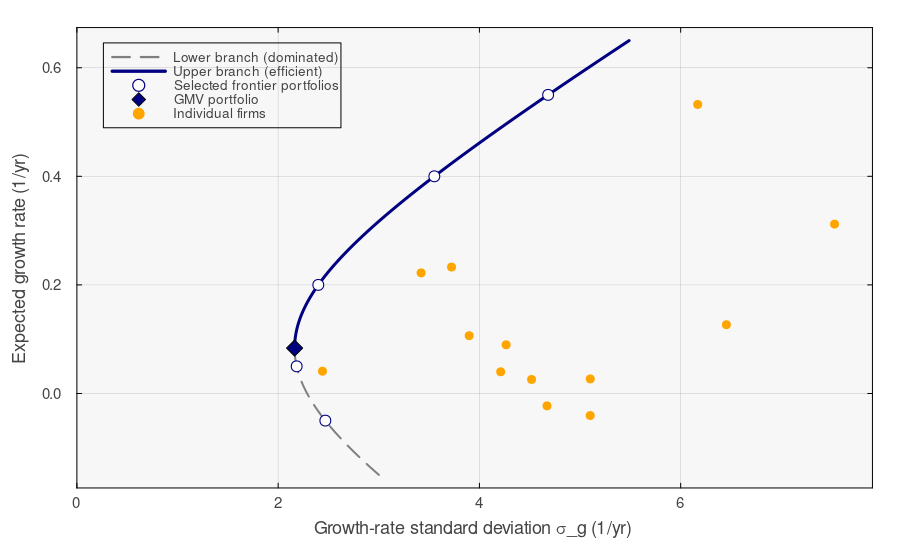

In [ ]:
let
    # Draw the two branches of the minimum-variance frontier -
    p = plot(σ_lower, g_lower, c = :gray50, ls = :dash,
        label = "Lower branch (dominated)");
    plot!(p, σ_upper, g_upper, c = :navy, lw = 3,
        label = "Upper branch (efficient)");

    # Mark the selected portfolios, the GMV portfolio, and the individual firms -
    scatter!(p, σ_targets, plot_targets, ms = 6, c = :white, msc = :navy,
        label = "Selected frontier portfolios");
    scatter!(p, [σ_GMV], [g_GMV], ms = 8, c = :navy, marker = :diamond,
        label = "GMV portfolio");
    scatter!(p, σ_firms, ĝ, ms = 5, c = :orange, msc = :orange,
        label = "Individual firms");

    # Show every plotted point and retain space for the axis labels -
    σ_plot_max = 1.05*maximum(vcat(σ_lower, σ_upper, σ_targets, σ_firms));
    plot!(p, xlabel = "Growth-rate standard deviation σ_g (1/yr)",
        ylabel = "Expected growth rate (1/yr)", xlims = (0, σ_plot_max),
        size = (900, 550), legend = :topleft, legendfontsize = 9,
        guidefontsize = 12, tickfontsize = 10, margin = 5Plots.mm)
end


The GMV portfolio is the leftmost point of the frontier. With these estimated
inputs, no fully invested portfolio of the selected firms has a smaller
growth-rate standard deviation. Moving up the efficient branch requires more
risk to achieve a higher expected growth rate. Below the GMV growth rate, each
frontier portfolio has the same standard deviation as a portfolio on the upper
branch but lower expected growth, which explains why the lower branch is dominated.

Each orange point represents a portfolio with all its weight in one firm.
That allocation is feasible at the firm's own mean growth rate, so the
minimum-variance portfolio at the same growth rate can have no greater risk.
This is why every firm lies on or to the right of the frontier when compared
horizontally. The distance shows how much the standard deviation can be reduced
by combining assets while keeping that expected growth rate fixed.

We have traced the frontier in the risk-growth plane. In Task 2, we examine how
the portfolio weights change along it and show how two fixed portfolios can
generate the entire frontier.

___


## Task 2: Construct the Frontier from Two Funds
In this task, we construct two fixed frontier portfolios, show how their mixture
reproduces the weights at any growth target, and trace the resulting portfolios
on the risk-growth plot. A __fund__ here means a fixed portfolio of our selected
assets; its asset weights may include short positions.

### Choose the two funds
Recall the weight formula from Task 1:
$$
\mathbf{w}(g_{\star})
=\lambda(g_{\star})\mathbf{\Sigma}_g^{-1}\mathbf{1}
+\gamma(g_{\star})\mathbf{\Sigma}_g^{-1}\boldsymbol{\mu}_g.
$$
Changing the target changes the two multipliers, while the vectors
$\mathbf{\Sigma}_g^{-1}\mathbf{1}$ and
$\mathbf{\Sigma}_g^{-1}\boldsymbol{\mu}_g$ stay fixed. Their components sum to
$a$ and $b$, respectively. For $b\ne0$, we normalize these vectors to obtain
two fully invested portfolios:
$$
\mathbf{w}_{\mathrm{GMV}}=\frac{\mathbf{\Sigma}_g^{-1}\mathbf{1}}{a},
\qquad
\mathbf{w}_{D}=\frac{\mathbf{\Sigma}_g^{-1}\boldsymbol{\mu}_g}{b}.
$$
The denominators make each portfolio's weights sum to one:
$$
\mathbf{1}^{\top}\mathbf{w}_{\mathrm{GMV}}=\frac{a}{a}=1,
\qquad
\mathbf{1}^{\top}\mathbf{w}_{D}=\frac{b}{b}=1.
$$
The first fund is the GMV portfolio at target $b/a$. At target $c/b$, the
multiplier formulas give $\lambda=0$ and $\gamma=1/b$. Substitution into the
weight formula gives $\mathbf{w}_{D}$, so the second fund also lies on the frontier.

The condition $b\ne0$ is needed for this choice of second fund. If $b=0$, the
second vector's components sum to zero, so scaling it cannot produce a fully
invested portfolio. We could instead choose another frontier portfolio with a
target different from the GMV growth rate.


### Derive the mixing weight
Using the two fund definitions, we can rewrite the frontier weights as follows:
$$
\mathbf{w}(g_{\star})
=\lambda(g_{\star})a\,\mathbf{w}_{\mathrm{GMV}}
+\gamma(g_{\star})b\,\mathbf{w}_{D}.
$$
The budget equation from Task 1 requires $\lambda a+\gamma b=1$. Therefore,
the two coefficients multiplying the funds sum to one. Define the dimensionless
mixing weight $\alpha$ as the fraction allocated to the second fund:
$$
\alpha=\gamma(g_{\star})b=\frac{b(ag_{\star}-b)}{d},
\qquad
1-\alpha=\lambda(g_{\star})a.
$$
Substituting these expressions gives the two-fund representation:
$$
\boxed{
\mathbf{w}(g_{\star})
=(1-\alpha)\mathbf{w}_{\mathrm{GMV}}+\alpha\mathbf{w}_{D}.
}
$$
This is the __two-fund theorem__ for the fully invested frontier with short
positions allowed: every frontier allocation can be constructed from two fixed
frontier portfolios. The target enters only through $\alpha$; the asset weights
within each fund stay fixed.

At $\alpha=0$, we hold the GMV fund alone; at $\alpha=1$, we hold the second fund
alone. For $0<\alpha<1$, we split wealth between the two funds. For $\alpha<0$
or $\alpha>1$, one fund is shorted to finance a larger position in the other.


### Connect the mixture to expected growth
How does changing $\alpha$ move us along the frontier? The two funds have
expected growth rates $b/a$ and $c/b$, so the mixture's expected growth is given by:
$$
\begin{aligned}
g_{\star}
&=(1-\alpha)\frac{b}{a}+\alpha\frac{c}{b}\\
&=\frac{b}{a}+\alpha\frac{ac-b^2}{ab}\\
&=\frac{b}{a}+\alpha\frac{d}{ab}.
\end{aligned}
$$
Since $a>0$ and $d>0$, the sign of $b$ determines whether increasing $\alpha$
raises or lowers expected growth. For our estimated inputs, $b>0$: positive
$\alpha$ moves above the GMV growth rate onto the efficient branch, while
negative $\alpha$ moves below it onto the dominated branch. If $b<0$, these
directions reverse.

For the numerical calculation, we substitute the estimates $\mathbf{g}^{\prime}$
and $\hat{\mathbf{\Sigma}}_g$ and store the fund weights in the
`w_GMV::Vector{Float64}` and `w_D::Vector{Float64}` variables. Let's construct
the two funds and check the mixture identity at a few growth targets:


In [ ]:
# Normalize the two directions computed in Task 1 -
w_GMV = frontier_parameters.x/a; # first fund's asset weights (dimensionless)
@assert !iszero(b) # required to normalize the second direction
w_D = frontier_parameters.y/b; # second fund's asset weights (dimensionless)


Let's summarize the two funds. Their asset weights should each sum to one.
The mean growth rate and standard deviation give their coordinates on the
frontier and will serve as reference points when we mix the funds:


In [ ]:
let
    # Summarize the budget, expected growth, and risk of each fund -
    df = DataFrame(
        "Fund" => ["GMV", "Second fund"],
        "Weight sum" => round.([sum(w_GMV), sum(w_D)], digits = 4),
        "Mean growth (1/yr)" => round.([ĝ'*w_GMV, ĝ'*w_D], digits = 4),
        "σ_g (1/yr)" => round.([sqrt(w'*Σ̂_g*w) for w ∈ [w_GMV, w_D]], digits = 4)
    );
    pretty_table(Matrix(df), backend = :text, column_labels = names(df),
        alignment = [:l, :r, :r, :r], fit_table_in_display_horizontally = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end


 ------------- ------------ -------------------- ------------
  Fund          Weight sum   Mean growth (1/yr)   σ_g (1/yr)
 ------------- ------------ -------------------- ------------
  GMV                  1.0               0.0836       2.1635
  Second fund          1.0               0.7898         6.65
 ------------- ------------ -------------------- ------------


Both funds are fully invested. With these estimates, the second fund has
higher expected growth and a larger standard deviation than the GMV fund,
consistent with their positions on the frontier.

### Check the mixture against the closed form
We now choose four growth targets. For each target, we calculate $\alpha$,
combine the two funds, and compare the resulting asset weights with those from
[the `frontier_weights(...)` function](docs/frontier-geometry.md#frontier_weights).
The largest absolute difference across assets measures how closely the mixture
reproduces the closed-form allocation.

We store the target, mixing weight, and difference in the
`mixture_results::DataFrame` variable. The check compares the unrounded weight
vectors; we round only when displaying the table:


In [ ]:
mixture_results = let
    # Store the mixing weight and comparison at each target -
    results = DataFrame(
        g_target = Float64[],
        α = Float64[],
        weight_difference = Float64[]
    );

    for g_target ∈ [-0.05, 0.10, 0.30, 0.55] # growth targets (1/yr)
        # Form the two-fund mixture and compare its asset weights -
        α = b*(a*g_target - b)/d; # fraction in the second fund (dimensionless)
        w_mix = (1 - α)*w_GMV + α*w_D; # resulting asset weights
        w_closed = frontier_weights(g_target, frontier_parameters);
        @assert isapprox(w_mix, w_closed, atol = 1e-10)
        weight_difference = maximum(abs.(w_mix .- w_closed)); # dimensionless
        push!(results, (g_target, α, weight_difference));
    end
    results; # return the unrounded comparison values
end;


The next table separates the fractions invested in the __funds__ from the
weights of the individual assets inside them. The GMV fund receives $1-\alpha$
and the second fund receives $\alpha$; these fractions sum to one and may be
negative or greater than one. The final column reports the maximum absolute
difference between the mixture's asset weights and the closed-form weights:


In [ ]:
let
    # Display the fund fractions and agreement of the asset weights -
    df = DataFrame(
        "Target growth (1/yr)" => mixture_results.g_target,
        "1−α (GMV fund)" => round.(1 .- mixture_results.α, digits = 3),
        "α (second fund)" => round.(mixture_results.α, digits = 3),
        "Max weight difference" => round.(mixture_results.weight_difference, sigdigits = 2)
    );
    pretty_table(Matrix(df), backend = :text, column_labels = names(df),
        fit_table_in_display_horizontally = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end


 ---------------------- ---------------- ----------------- -----------------------
  Target growth (1/yr)   1−α (GMV fund)   α (second fund)   Max weight difference
 ---------------------- ---------------- ----------------- -----------------------
                 -0.05            1.189            -0.189                 1.1e-16
                   0.1            0.977             0.023                 1.1e-16
                   0.3            0.694             0.306                 5.6e-17
                  0.55             0.34              0.66                 1.1e-16
 ---------------------- ---------------- ----------------- -----------------------


The weight differences are near zero, so the two-fund mixture reproduces the
closed-form allocation at each target. For these inputs, the first target is
below the GMV growth rate: $\alpha<0$, so a short position in the second fund
finances a position greater than one in the GMV fund. The other displayed
targets lie between the two funds' growth rates and use positive fractions in
both funds. We next vary the mixing weight over a wider range to see how these
allocations trace the frontier.


### Trace the frontier by mixing the funds

Let's now vary $\alpha$ from $-1$ to $2.5$ to include portfolios on both sides
of the GMV fund and beyond the second fund. For each value, we construct the
asset-weight vector $\mathbf{w}_{\mathrm{mix}}(\alpha)$ and calculate its estimated
expected growth rate and standard deviation:
$$
\begin{aligned}
g_{\mathrm{mix}}^{\prime}(\alpha)
&=(\mathbf{g}^{\prime})^{\top}\mathbf{w}_{\mathrm{mix}}(\alpha),\\
\sigma_{g,\mathrm{mix}}(\alpha)
&=\sqrt{\mathbf{w}_{\mathrm{mix}}(\alpha)^{\top}
\hat{\mathbf{\Sigma}}_g\mathbf{w}_{\mathrm{mix}}(\alpha)}.
\end{aligned}
$$
We store these coordinates in the `g_mix::Vector{Float64}` and
`σ_mix::Vector{Float64}` variables. For comparison, we also evaluate the
closed-form frontier over the same growth range, including the GMV point:


In [ ]:
# Construct the asset weights for each fund mixture -
α_values = collect(range(-1.0, stop = 2.5, length = 36)); # second-fund fractions
mixture_weights = [(1-α)*w_GMV + α*w_D for α ∈ α_values];

# Calculate each mixture's expected growth and standard deviation -
g_mix = [ĝ'*w for w ∈ mixture_weights]; # expected growth rates (1/yr)
σ_mix = [sqrt(w'*Σ̂_g*w) for w ∈ mixture_weights]; # standard deviations (1/yr)

# Trace the closed-form curve across the full mixture range, through the GMV -
g_mix_curve = vcat(
    range(minimum(g_mix), stop = g_GMV, length = 151),
    range(g_GMV, stop = maximum(g_mix), length = 151),
);
σ_mix_curve = sqrt.(frontier_variance.(g_mix_curve, Ref(frontier_parameters))); # 1/yr


The gray curve shows the closed-form frontier, and the red circles show the
36 portfolios constructed by mixing the funds. We mark the GMV fund
($\alpha=0$) and second fund ($\alpha=1$) with larger filled circles so we can
relate the mixing fractions to their positions on the curve:


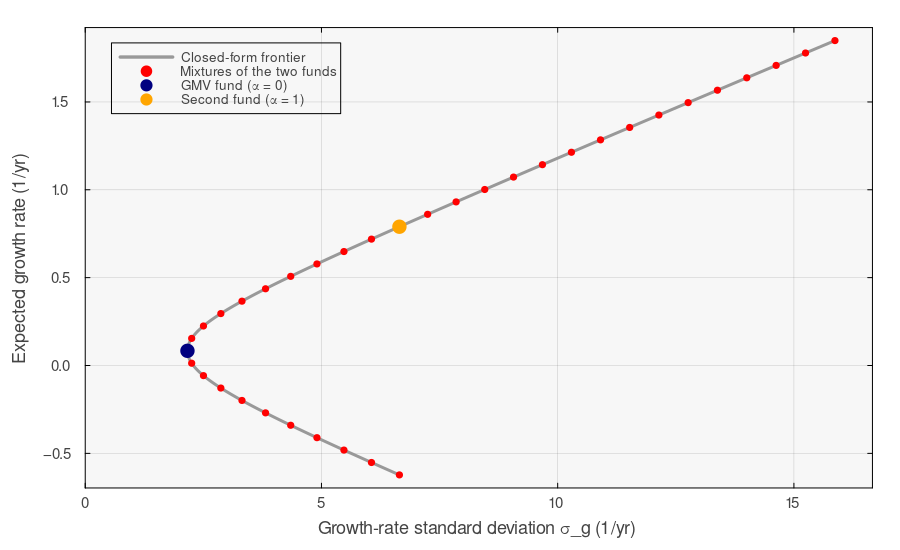

In [ ]:
let
    # Compare the fund mixtures with the closed-form frontier -
    p = plot(σ_mix_curve, g_mix_curve, c = :gray60, lw = 3,
        label = "Closed-form frontier");
    scatter!(p, σ_mix, g_mix, ms = 4, c = :red, msc = :red, marker = :circle,
        label = "Mixtures of the two funds");

    # Identify the two funds used to construct the mixtures -
    scatter!(p, [σ_GMV], [g_GMV], ms = 8, c = :navy, msc = :navy, marker = :circle,
        label = "GMV fund (α = 0)");
    scatter!(p, [sqrt(w_D'*Σ̂_g*w_D)], [ĝ'*w_D], ms = 8,
        c = :orange, msc = :orange, marker = :circle,
        label = "Second fund (α = 1)");

    # Keep the complete mixture range visible -
    σ_plot_max = 1.05*maximum(vcat(σ_mix_curve, σ_mix));
    plot!(p, xlabel = "Growth-rate standard deviation σ_g (1/yr)",
        ylabel = "Expected growth rate (1/yr)", xlims = (0, σ_plot_max),
        size = (900, 550), legend = :topleft, legendfontsize = 9,
        guidefontsize = 12, tickfontsize = 10, margin = 5Plots.mm)
end


All mixtures lie on the frontier. For these inputs, $\alpha<0$ traces the lower
branch, while $\alpha>1$ shorts the GMV fund to increase the position in the second
fund. The weights change linearly with $\alpha$, but the risk-growth path is curved
because variance is quadratic in the weights.

Any two distinct frontier funds can generate this curve with unrestricted mixing
fractions. Under the [lecture's risk-free-asset assumptions](../../CHEME-5660-L5b-Lecture-MAGBM-Data-Portfolios-Fall-2026.ipynb),
efficient complete portfolios instead combine the risk-free asset and tangent
portfolio along the capital allocation line.

Next, we add bounds on the asset weights and examine their effect on minimum risk.

___


## Task 3: Compare the Cost of Weight Constraints

How much additional standard deviation do weight constraints require at the same
expected growth rate? We retain the budget and equality growth constraints from
Task 1 and compare three rules for each asset weight:

| Weight rule | Allowed weights |
| :--- | :--- |
| Unconstrained | $w_i\in\mathbb{R}$ |
| Position cap | $-0.5\leq w_i\leq0.5$ |
| Long-only | $0\leq w_i\leq1$ |

Both bounded sets restrict the unconstrained problem, so neither can lower its
minimum risk at a shared feasible target. The two bounded sets are not nested:
the position cap allows shorts, while long-only permits individual weights above
$0.5$. Their relative cost therefore depends on the inputs and target.

Each tuple below stores the rule's label and its lower and upper weight bounds:


In [ ]:
# Define the three weight rules; bounds are dimensionless -
constraint_cases = [
    ("unconstrained", -Inf, Inf),
    ("|w_i| ≤ 0.5", -0.5, 0.5),
    ("long only", 0.0, 1.0),
];


### Find the starting point for each frontier

Each efficient branch begins at its own GMV portfolio. We first minimize variance
under the budget constraint and the selected weight bounds, without imposing a
growth target. The resulting weights are stored by rule in the
`gmv_weights::Dict{String,Vector{Float64}}` variable:


In [ ]:
gmv_weights = let
    results = Dict{String,Vector{Float64}}();
    for (name, lower, upper) ∈ constraint_cases
        # Minimize variance with the budget and weight bounds only -
        model = Model(() -> MadNLP.Optimizer(
            print_level = MadNLP.ERROR, max_iter = 500));
        @variable(model, lower ≤ w[i = 1:M] ≤ upper, start = 1/M);
        @objective(model, Min, w'*Σ̂_g*w);
        @constraint(model, sum(w) == 1.0);

        # Solve and retain the GMV weights for this rule -
        optimize!(model);
        @assert is_solved_and_feasible(model)
        results[name] = value.(w);
    end
    results
end;


### Sweep the efficient branches

For each rule, we use its GMV expected growth as the first target and solve at
60 evenly spaced targets. The common upper target is just below the largest
firm mean, since a long-only portfolio cannot exceed that mean.

The [`solve_frontier_point(...)` function](docs/frontier-geometry.md#solve_frontier_point)
enforces the equality growth target along with the budget and selected bounds.
We retain solved, feasible points and store their target growth and standard
deviation in the `frontiers::Dict{String,DataFrame}` variable:


In [ ]:
# Choose a common upper target and the number of targets per rule -
g_max = maximum(ĝ) - 1e-3; # upper growth target (1/yr)
number_of_targets = 60; # points sampled along each efficient branch

frontiers = let
    results = Dict{String,DataFrame}();
    for (name, lower, upper) ∈ constraint_cases
        g_min = ĝ'*gmv_weights[name]; # this rule's GMV growth rate (1/yr)
        points = DataFrame(g = Float64[], σ = Float64[]);
        for g_target ∈ range(g_min, stop = g_max, length = number_of_targets)
            w_opt = solve_frontier_point(g_target, ĝ, Σ̂_g;
                lower = lower, upper = upper);
            w_opt === nothing && continue
            σ = sqrt(w_opt'*Σ̂_g*w_opt); # frontier standard deviation (1/yr)
            push!(points, (g = g_target, σ = σ));
        end
        results[name] = points;
    end
    results
end;


Let's report the number of solved targets and the GMV starting point for
each rule:


In [ ]:
let
    # Summarize the sweep and its GMV starting portfolio for each rule -
    case_names = first.(constraint_cases);
    summary = DataFrame(
        "Weight rule" => case_names,
        "Points" => [nrow(frontiers[name]) for name ∈ case_names],
        "GMV growth (1/yr)" => [round(ĝ'*gmv_weights[name], digits = 4)
            for name ∈ case_names],
        "GMV σ_g (1/yr)" => [round(sqrt(gmv_weights[name]'*Σ̂_g*gmv_weights[name]),
            digits = 4) for name ∈ case_names],
    );
    pretty_table(Matrix(summary), backend = :text, column_labels = names(summary),
        alignment = [:l, :r, :r, :r], fit_table_in_display_horizontally = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end


 --------------- -------- ------------------- ----------------
  Weight rule     Points   GMV growth (1/yr)   GMV σ_g (1/yr)
 --------------- -------- ------------------- ----------------
  unconstrained       60              0.0836           2.1635
  |w_i| ≤ 0.5         60              0.0919           2.1886
  long only           60              0.0818           2.1749
 --------------- -------- ------------------- ----------------


All three sweeps produce 60 points. For these inputs, the capped GMV has
slightly more risk than the long-only GMV. These starting portfolios have
different growth rates; the frontier curves let us compare the rules at the
same growth target.


### Compare the frontiers at the same growth target

Let's plot the three efficient branches. The orange line is drawn wider so it
remains visible where the capped and unconstrained frontiers overlap. Filled
gray circles show individual firms as reference points:


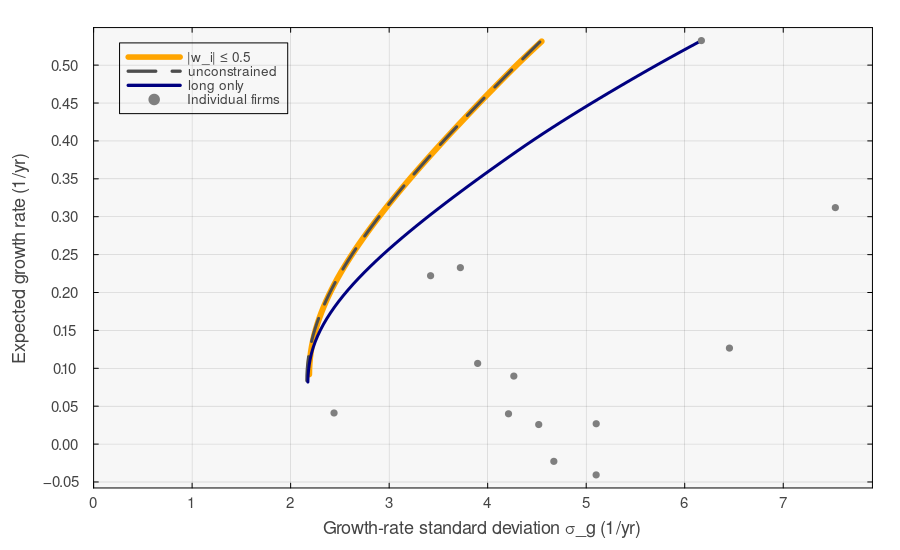

In [ ]:
let
    # Draw the capped curve first so overlapping frontiers remain visible -
    styles = [
        ("|w_i| ≤ 0.5", :orange, :solid, 6),
        ("unconstrained", :gray30, :dash, 3),
        ("long only", :navy, :solid, 3),
    ];
    p = plot();
    for (name, color, line_style, width) ∈ styles
        points = frontiers[name];
        plot!(p, points.σ, points.g, c = color, ls = line_style,
            lw = width, label = name);
    end
    scatter!(p, σ_firms, ĝ, ms = 4, c = :gray50, msc = :gray50,
        marker = :circle, label = "Individual firms");

    # Include every frontier point and individual firm -
    σ_frontier_max = maximum(maximum(points.σ) for points ∈ values(frontiers));
    σ_plot_max = 1.05*max(maximum(σ_firms), σ_frontier_max);
    plot!(p, xlabel = "Growth-rate standard deviation σ_g (1/yr)",
        ylabel = "Expected growth rate (1/yr)", xlims = (0, σ_plot_max),
        xticks = 0:1:σ_plot_max, yticks = -0.05:0.05:0.55,
        size = (900, 550), legend = :topleft, legendfontsize = 9,
        guidefontsize = 12, tickfontsize = 10, margin = 5Plots.mm)
end


Compare the curves horizontally at a common growth target. The capped and
unconstrained curves nearly coincide at higher targets, while long-only requires more
risk there. The firm markers represent investments entirely in one firm,
which violate the position cap. Let's quantify the gaps between the curves.


### Quantify the increase in standard deviation

At each selected target, we divide the constrained standard deviation by the
unconstrained value:
$$
\mathcal{R}_{\mathrm{rule}}(g_{\star})
=\frac{\sigma_{g,\mathrm{rule}}(g_{\star})}
{\sigma_{g,\mathrm{unconstrained}}(g_{\star})}.
$$
A ratio of $1.10$ means $10\%$ more standard deviation at the same expected growth.
The ratio is dimensionless.

Because each grid starts at a different GMV growth rate, we use
[`interpolate_frontier_risk(...)`](docs/frontier-geometry.md#interpolate_frontier_risk)
to interpolate standard deviation linearly between neighboring grid points.
We store the comparisons in the `risk_comparison::DataFrame` variable:


In [ ]:
comparison_targets = [0.10, 0.20, 0.30, 0.40, 0.50]; # shared growth targets (1/yr)

risk_comparison = let
    results = DataFrame(g_target = Float64[], σ_unconstrained = Float64[],
        ratio_cap = Float64[], ratio_long_only = Float64[]);
    for g_target ∈ comparison_targets
        # Estimate standard deviation at the same target on each frontier -
        σ_unconstrained = interpolate_frontier_risk(frontiers["unconstrained"], g_target);
        σ_capped = interpolate_frontier_risk(frontiers["|w_i| ≤ 0.5"], g_target);
        σ_long_only = interpolate_frontier_risk(frontiers["long only"], g_target);

        # Normalize the constrained risks by the unconstrained risk -
        push!(results, (g_target, σ_unconstrained,
            σ_capped/σ_unconstrained, σ_long_only/σ_unconstrained));
    end
    results
end;


The table reports the unconstrained standard deviation and the two risk ratios,
rounded to three decimal places:


In [ ]:
let
    comparison_table = DataFrame(
        "Target growth (1/yr)" => risk_comparison.g_target,
        "Unconstrained σ_g (1/yr)" => round.(risk_comparison.σ_unconstrained, digits = 3),
        "Cap ratio" => round.(risk_comparison.ratio_cap, digits = 3),
        "Long-only ratio" => round.(risk_comparison.ratio_long_only, digits = 3),
    );
    pretty_table(Matrix(comparison_table), backend = :text,
        column_labels = names(comparison_table), fit_table_in_display_horizontally = false,
        formatters = [fmt__printf("%.2f", [1]), fmt__printf("%.3f", [2, 3, 4])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end


 ---------------------- -------------------------- ----------- -----------------
  Target growth (1/yr)   Unconstrained σ_g (1/yr)   Cap ratio   Long-only ratio
 ---------------------- -------------------------- ----------- -----------------
                  0.10                      2.169       1.010             1.007
                  0.20                      2.399       1.001             1.067
                  0.30                      2.897       1.000             1.171
                  0.40                      3.552       1.000             1.253
                  0.50                      4.293       1.000             1.331
 ---------------------- -------------------------- ----------- -----------------


At $g_{\star}=0.10\ \mathrm{yr}^{-1}$, the cap adds about $1\%$ to standard
deviation. The long-only cost increases across the reported targets, reaching
about $33.1\%$ at $g_{\star}=0.50\ \mathrm{yr}^{-1}$.

The unconstrained GMV puts $61.6\%$ in JNJ, violating the cap. At targets $0.30$
and $0.40$, the unconstrained weights meet the cap, but a $53.9\%$ position violates
it again at $0.50$. The ratio rounded to $1.000$ therefore does not always mean
the cap is inactive.

Long-only prevents financing higher-growth assets with short positions. These
comparisons use fixed estimates; the
[estimation-risk example](../estimation-risk/CHEME-5660-L5b-Advanced-EstimationRisk-Fall-2026.ipynb)
examines how the weights change when we estimate those inputs again.

___


## Summary

With the estimated means and covariance fixed, each growth target determines a
unique unconstrained minimum-variance allocation. We derived its weights,
explained how those allocations form a frontier, and measured how restrictions
on the weights change the minimum achievable risk.

> __Key Takeaways:__
>
> - **Minimum variance and the efficient branch:** We used two Lagrange multipliers to derive the optimal weights and a quadratic expression for their variance. Completing the square identified the GMV target $b/a$ and variance $1/a$, and showed why targets above or below $b/a$ require more risk. The upper branch is efficient because a lower-branch portfolio offers less expected growth than an upper-branch portfolio with the same standard deviation.
>
> - **Two-fund representation:** We rewrote the optimal weights as $(1-\alpha)\mathbf{w}_{\mathrm{GMV}}+\alpha\mathbf{w}_D$. Changing the growth target changes $\alpha$ while the asset weights within each fund stay fixed. Allowing one fund to be shorted extends the construction beyond the two funds and generates the entire unconstrained frontier. The same construction works with any two distinct frontier portfolios.
>
> - **The risk cost of weight constraints:** We compared weight rules at the same growth target. A rule increases minimum risk when it excludes the unconstrained optimum; the $50\%$ position limit and long-only rule are not ordered by strictness because their feasible sets are not nested. For our inputs at $g_{\star}=0.50\ \mathrm{yr}^{-1}$, long-only increased standard deviation by about $33.1\%$, while the $50\%$ position limit added about $0.03\%$. Inspecting the weights showed that the $50\%$ position limit still excluded the optimum even though its reported risk ratio rounded to $1.000$.

The frontier describes what we can achieve for a given set of estimated inputs.
The [estimation-risk example](../estimation-risk/CHEME-5660-L5b-Advanced-EstimationRisk-Fall-2026.ipynb)
asks how much the chosen weights change when we estimate those inputs again.

___


## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
